# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

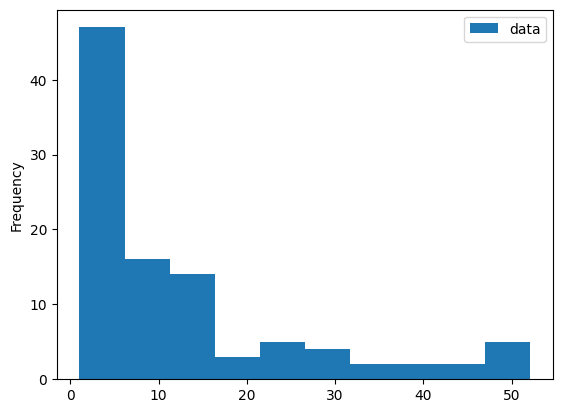

In [5]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

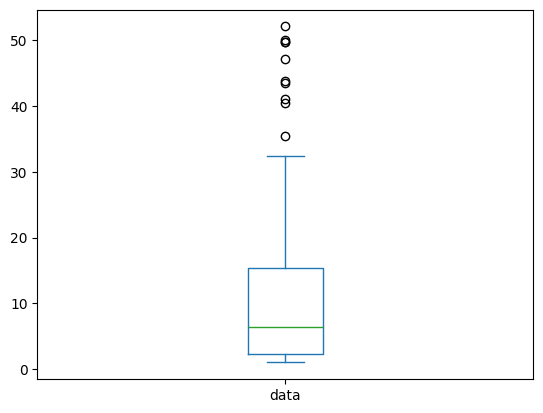

In [6]:
df.plot.box()

The better graph is histogram. The boxplot just shows how skewed the prices are.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

There are many different analyses that can be performed on this dataset. We can look at The "Who’s Attacking?" (Bar or Pie Chart), Incident Timeline (Line Graph), Industry Vulnerability (Horizontal Bar Chart), Geopolitical Alliance Heatmap (Heatmap), Actor vs. Industry (Grouped Bar Chart), and Change Log Latency (Histogram).


In [11]:
# Import the dataset and make DataFrame
df_cyber_events = pd.read_csv('cyber_events.csv', encoding='ISO-8859-1', dtype={'change_log': str})

df_cyber_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 16532 entries, 0 to 16531
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   slug                16532 non-null  str  
 1   original_method     16532 non-null  int64
 2   event_date          16532 non-null  str  
 3   reported_date       1977 non-null   str  
 4   year                16532 non-null  int64
 5   month               16532 non-null  int64
 6   actor               16532 non-null  str  
 7   actor_type          16532 non-null  str  
 8   organization        16532 non-null  str  
 9   industry_code       16532 non-null  int64
 10  industry            16532 non-null  str  
 11  motive              16532 non-null  str  
 12  event_type          16532 non-null  str  
 13  event_subtype       16532 non-null  str  
 14  magnitude           716 non-null    str  
 15  duration            692 non-null    str  
 16  scope               719 non-null    str  
 17  ip  

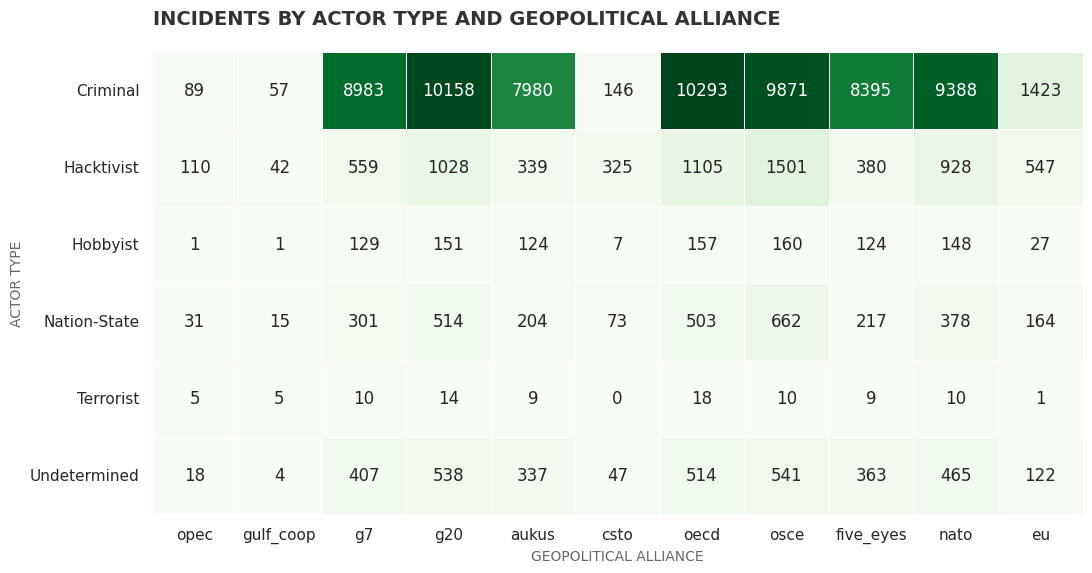

In [10]:
# Clean the data a little
# Clean columns that have nulls
df_cleaned_cyber = df_cyber_events.dropna(axis=1)

df_cleaned_cyber.head()


,slug,original_method,event_date,year,month,actor,actor_type,organization,industry_code,industry,...,asean,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes
0,1f72c2eb8ab303e4,1,1/1/14,2014,1,Undetermined,Criminal,Barry University,61,Educational Services,...,0,0,0,1,1,1,0,1,1,1
1,ecac8b3e60a2f72f,1,1/1/14,2014,1,Undetermined,Criminal,Record Assist LLC,54,"Professional, Scientific, and Technical Services",...,0,0,0,1,1,1,0,1,1,1
2,3bbe0695e2d019f3,1,1/1/14,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,"Professional, Scientific, and Technical Services",...,0,0,0,1,1,1,0,1,1,1
3,6100014f6ca84b3d,1,1/2/14,2014,1,Undetermined,Criminal,Snapchat,51,Information,...,0,0,0,1,1,1,0,1,1,1
4,3a94b8cf6dde1f66,1,1/3/14,2014,1,DERP Trolling,Undetermined,Battle.net,51,Information,...,0,0,0,1,1,1,0,1,1,1


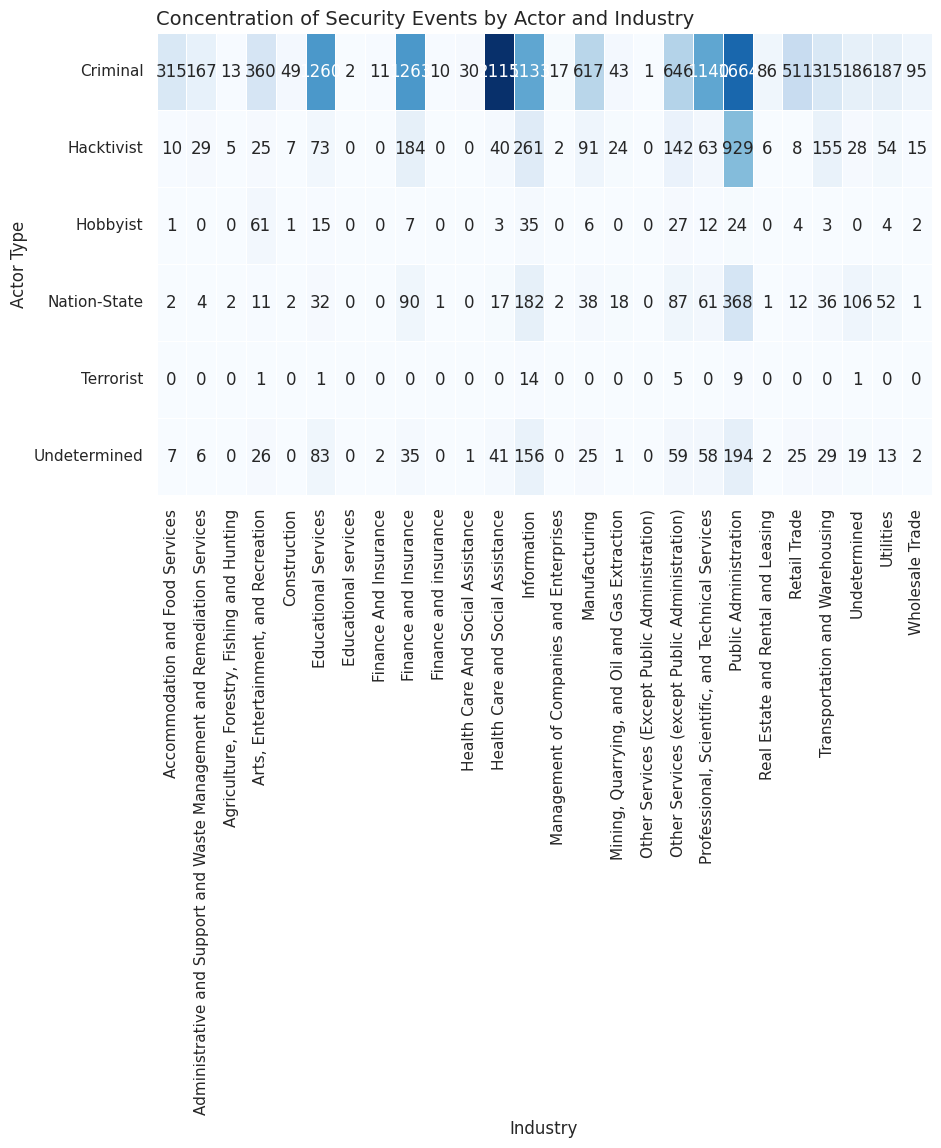

In [26]:
# Looks at actor type and industry they are targeting

# Prepare your data (Pivot or Crosstab)
# This counts how many times each actor type hits each industry
ct = pd.crosstab(df_cleaned_cyber['actor_type'], df_cleaned_cyber['industry'])

# Set the style to be clean and minimal
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# Create the Heatmap
# Use 'Blues' or 'Greys' for a monochromatic look
ax = sns.heatmap(ct, 
                 annot=True,     # Show the numbers in the cells
                 fmt="d",        # Format as integers
                 cmap="Blues",   # Monochromatic color scale
                 cbar=False,     # Remove the color bar to keep it simple
                 linewidths=.5)  # Add subtle borders between cells

# 4. Final touches following Knaflic's principles
plt.title('Concentration of Security Events by Actor and Industry', fontsize=14, loc='left')
plt.xlabel('Industry')
plt.ylabel('Actor Type')
plt.show()

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

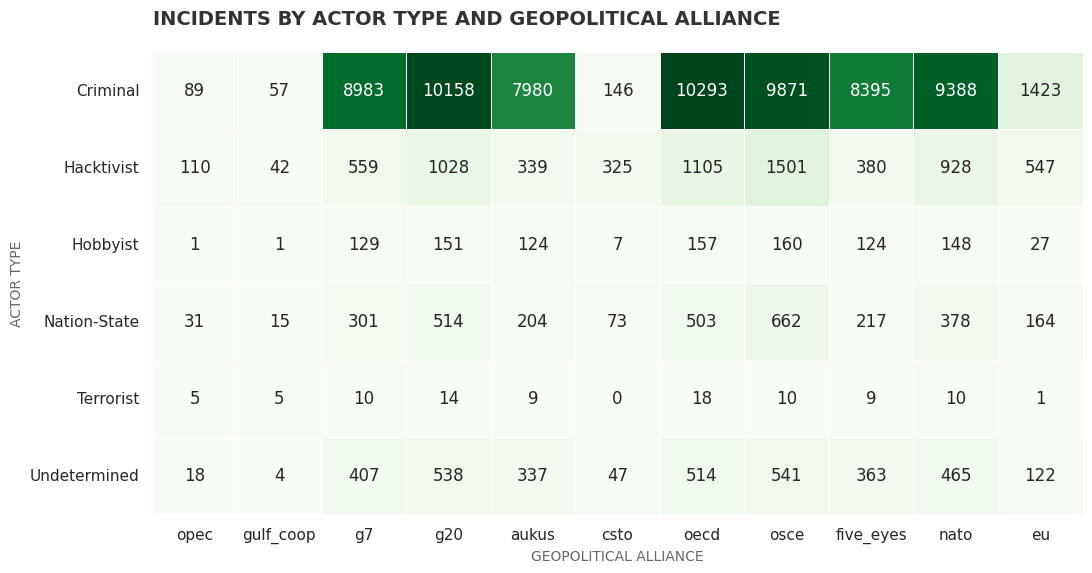

In [25]:
# Interesrted in the geopolitical alliances
# You can cross-reference the Actor Type against your alliance columns (g7, g20, five_eyes, etc.).

# Select and aggregate the alliance columns
alliances = ['opec', 'gulf_coop', 'g7', 'g20', 'aukus', 'csto', 'oecd', 'osce', 'five_eyes', 'nato', 'eu']
df_geo = df_cyber_events.groupby('actor_type')[alliances].sum()

# Set up the figure following Knaflic's "clean" aesthetic
plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

# Create the monochromatic heatmap
# Using 'Greens' or 'Blues' provides a clear intensity scale
ax = sns.heatmap(df_geo, 
                 annot=True,     # Numerical labels for clarity
                 fmt="g", 
                 cmap="Greens",  # Monochromatic scale
                 cbar=False,     # Remove colorbar to reduce clutter
                 linewidths=.5)

# Knaflic-style formatting: Left-aligned title and minimal labels
plt.title('INCIDENTS BY ACTOR TYPE AND GEOPOLITICAL ALLIANCE', 
          fontsize=14, loc='left', pad=20, fontweight='bold', color='#333333')
plt.xlabel('GEOPOLITICAL ALLIANCE', fontsize=10, color='#666666')
plt.ylabel('ACTOR TYPE', fontsize=10, color='#666666')

# Remove chart junk (spines)
sns.despine(left=True, bottom=True)

plt.show()